In [1]:
import sympy
from sympy import symbols, Function, Eq, solve, diff, integrate, pi, simplify



## 🛰 Example 1: Velocity from Position – Differentiation

Let’s say a planet’s distance from a star varies with time as:

$$
r(t) = a\bigl(1 - e\cos(\omega t)\bigr)
$$

Where:
- $a$ is semi‑major axis  
- $e$ is eccentricity  
- $\omega$ is angular frequency  

👉 **Task:** Find the radial velocity.

In [2]:
from sympy import symbols, cos, sin, pi, diff, simplify

# Step 1: Define symbols
t = symbols('t', real=True)                          # time in days
semi_major_axis = symbols('a', real=True, positive=True)           # semi-major axis in meters
eccentricity = symbols('e', real=True, positive=True)           # eccentricity
omega = symbols('omega', real=True, positive=True)   # angular frequency in rad/day

# Step 2: Define Pluto's orbital radius function
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))

# Step 3: Differentiate to get radial velocity
radial_velocityFunc = simplify(diff(radial_distanceFunc, t))  # This gives a*e*omega*sin(omega*t)



# Step 4: Define Pluto's orbital parameters
AU_m = 1.496e11                      # 1 AU in meters
a_pluto = 39.48 * AU_m              # semi-major axis in meters
e_pluto = 0.2488
T_pluto_days = 248 * 365.25
omega_pluto = 2 * pi / T_pluto_days
t_eval = 1000  # days

# Step 5: Substitute values
values = {
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto,
    t: t_eval
}

# Step 6: Evaluate in m/day, then convert to m/s
v_r_m_per_day = radial_velocityFunc.subs(values).evalf()
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)

# Step 7: Output
print("Pluto radial velocity at day 1000:")
print(f"{v_r_m_per_day:.2e} m/day")
print(f"{v_r_m_per_sec:.2f} m/s")

Pluto radial velocity at day 1000:
7.06e+6 m/day
81.77 m/s


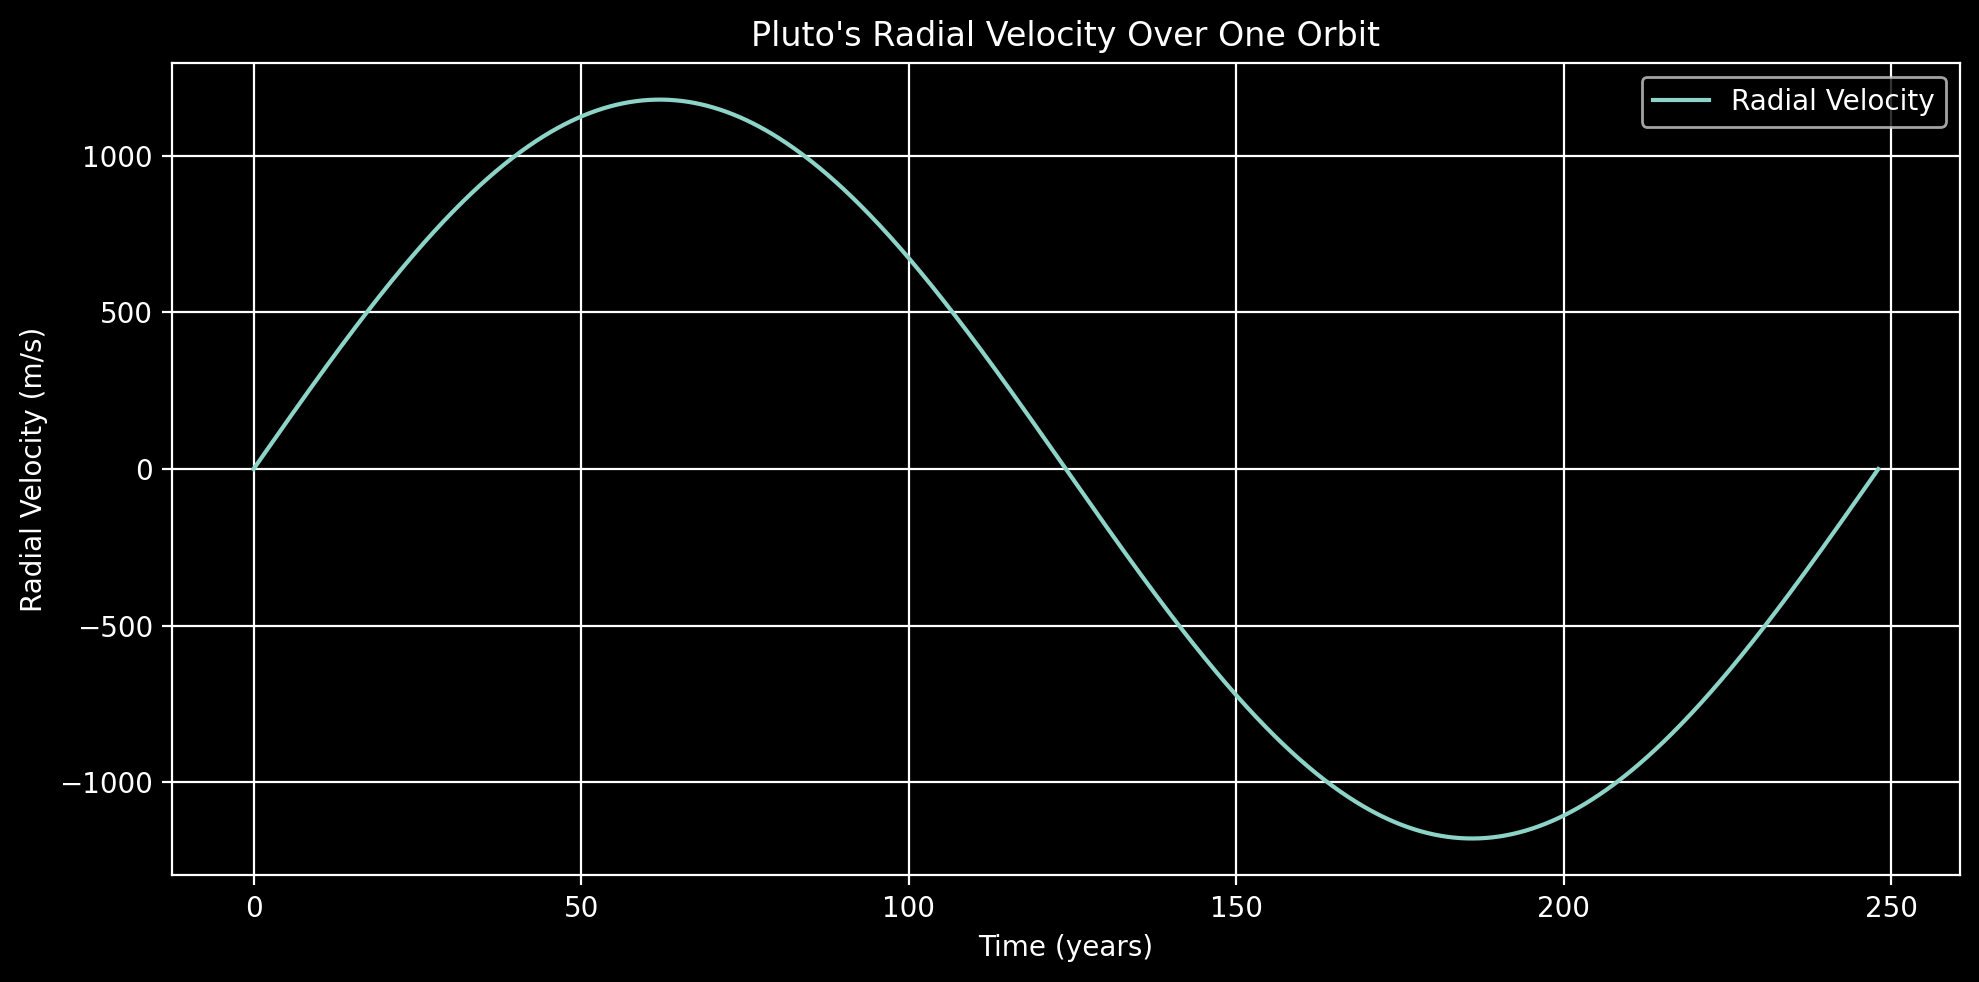

In [3]:
from sympy import symbols, cos, sin, pi, diff, simplify, lambdify
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define symbolic variables
t = symbols('t', real=True)                            # Time (days)
semi_major_axis = symbols('a', real=True, positive=True)             # Semi-major axis (meters)
eccentricity = symbols('e', real=True, positive=True)             # Eccentricity
omega = symbols('omega', real=True, positive=True)     # Angular frequency (rad/day)

# Step 2: Define orbital radius and differentiate to get radial velocity
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))                        # Radial distance as function of time
radial_velocityFunc = simplify(diff(radial_distanceFunc, t))                              # Radial velocity = dr/dt = a*e*omega*sin(omega*t)

# Step 3: Pluto’s orbital parameters
AU_meters = 1.496e11                                    # 1 AU in meters
a_pluto = 39.48 * AU_meters                             # Pluto's semi-major axis in meters
e_pluto = 0.2488                                        # Eccentricity
T_pluto_days = 248 * 365.25                             # Orbital period in days
omega_pluto = 2 * pi / T_pluto_days                     # Angular frequency in rad/day

# Step 4: Convert symbolic radial velocity to a numerical function
radial_velocityFunLamdify = lambdify(t, radial_velocityFunc.subs({
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto
}), modules='numpy')

# Step 5: Generate time values (days) and evaluate radial velocity in m/s
days = np.linspace(0, T_pluto_days, 1000)               # 1000 time points over full orbit
v_r_m_per_day = radial_velocityFunLamdify(days)                          # Evaluate radial velocity in m/day
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)             # Convert to m/s

# Step 6: Plot radial velocity over time
plt.figure(figsize=(10, 5))
plt.plot(days / 365.25, v_r_m_per_sec, label="Radial Velocity")  # Time in years
plt.title("Pluto's Radial Velocity Over One Orbit")
plt.xlabel("Time (years)")
plt.ylabel("Radial Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

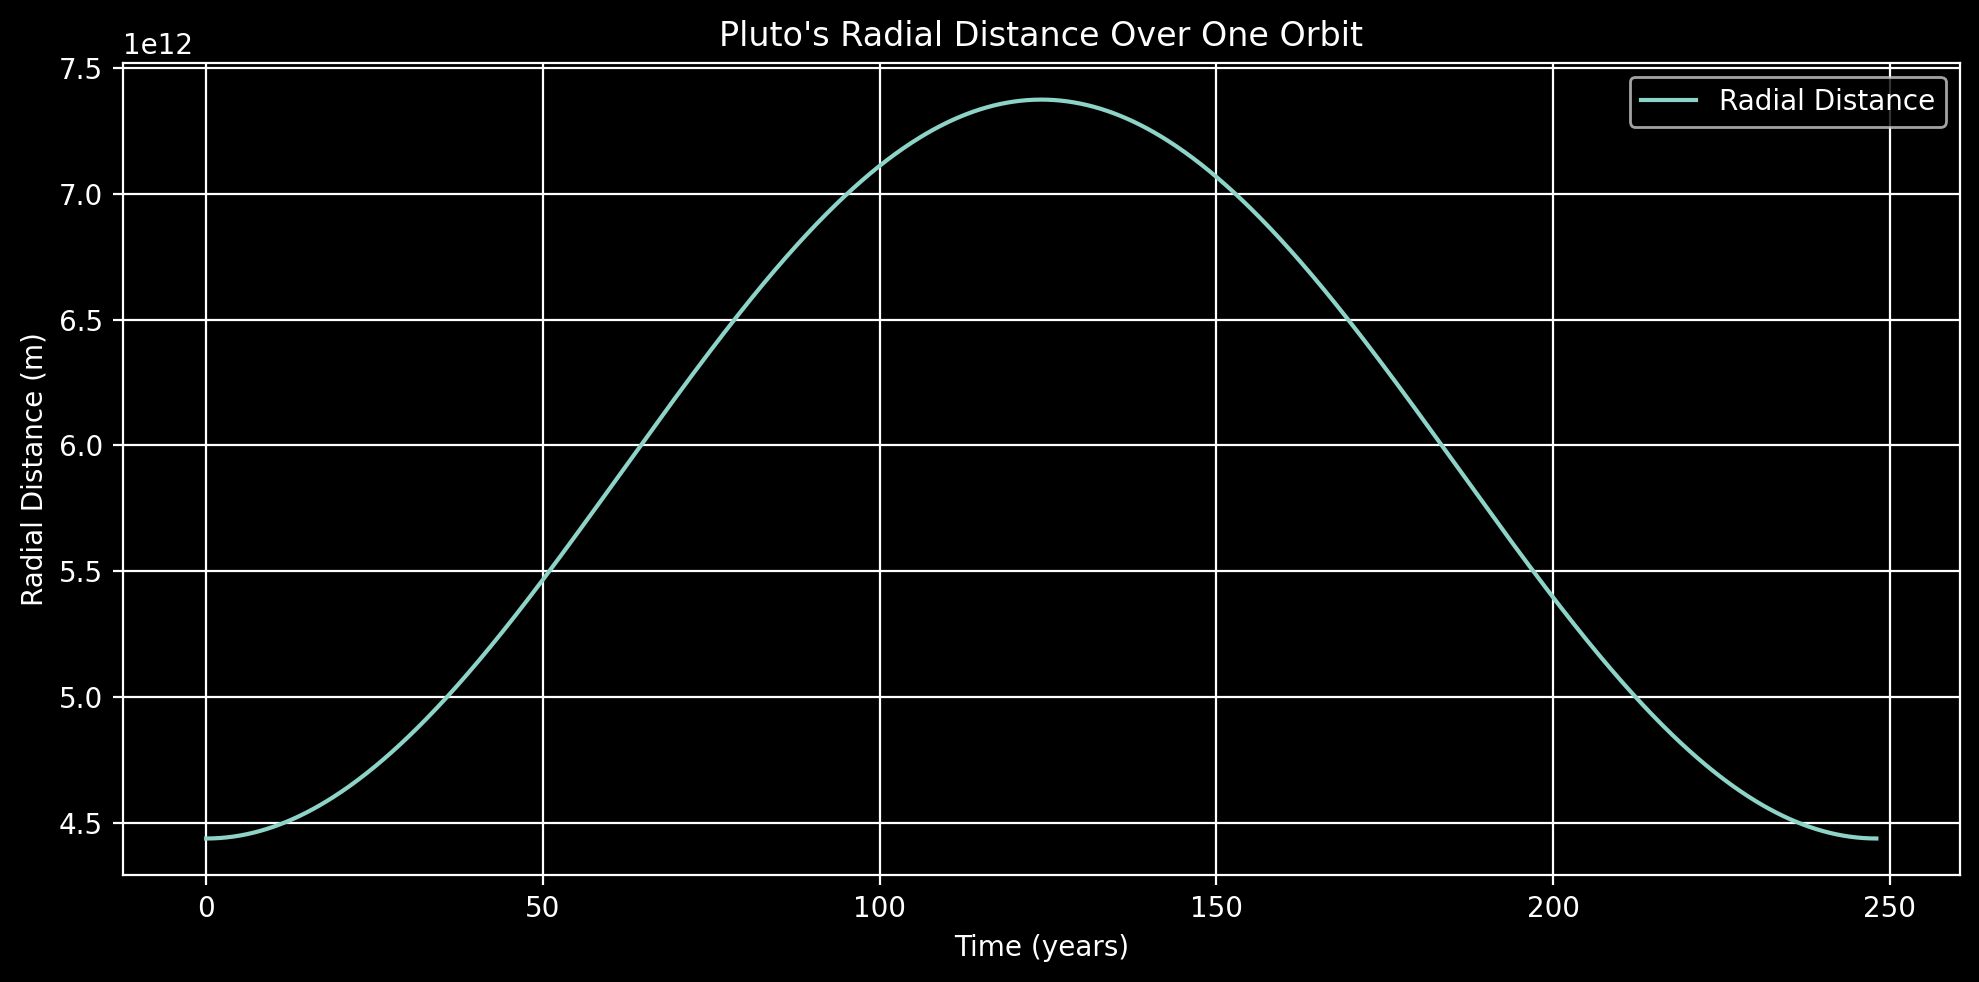

'Radial Velocity func'

a*e*omega*sin(omega*t)

'Radial Velocity func simplified'

a*e*omega*sin(omega*t)

def _lambdifygenerated(t):
    return 32444957.0643174*pi*sin(2.20794418317105e-5*pi*t)



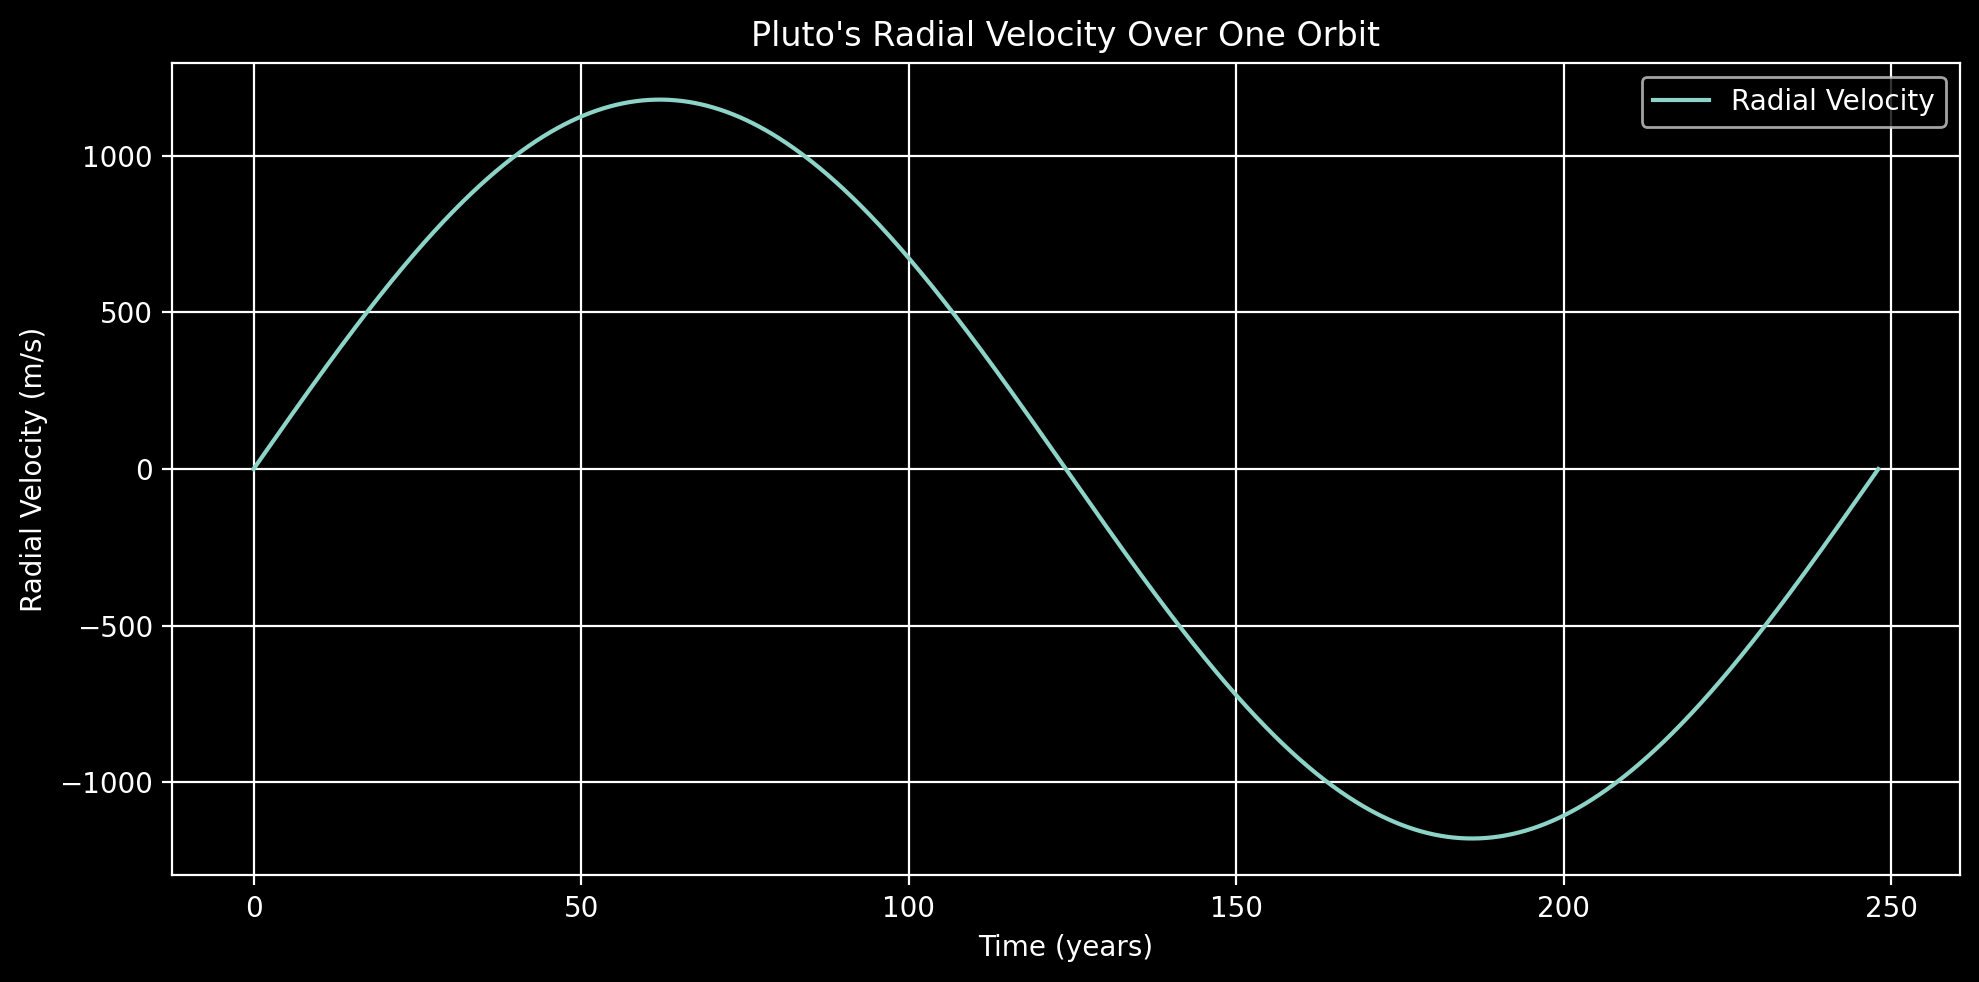

In [4]:
from sympy import symbols, cos, sin, pi, diff, simplify, lambdify
import numpy as np
import matplotlib.pyplot as plt
import inspect

# Define symbolic variables
t = symbols('t', real=True)                                     # Time (days)
semi_major_axis = symbols('a', real=True, positive=True)        # Semi-major axis (meters)
eccentricity = symbols('e', real=True, positive=True)           # Eccentricity
omega = symbols('omega', real=True, positive=True)              # Angular frequency (rad/day)

# Pluto’s orbital parameters
AU_meters = 1.496e11                                    # 1 AU in meters
a_pluto = 39.48 * AU_meters                             # Pluto's semi-major axis in meters
e_pluto = 0.2488                                        # Eccentricity
T_pluto_days = 248 * 365.25                             # Orbital period in days
omega_pluto = 2 * pi / T_pluto_days  

# Plot radial distance over one orbit 
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))                        # Radial distance as function of time
#Plot Pluto's radial distance over one orbit
radial_distanceFuncSimp = radial_distanceFunc.subs({
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto
})
radial_distanceFunLamdify = lambdify(t, radial_distanceFuncSimp, modules='numpy')
days = np.linspace(0, T_pluto_days, 1000)               # 1000 time points over full orbit
radial_distance_m = radial_distanceFunLamdify(days)     # Evaluate radial distance in meters
plt.figure(figsize=(10, 5))
plt.plot(days / 365.25, radial_distance_m, label="Radial Distance")  # Time in years
plt.title("Pluto's Radial Distance Over One Orbit")
plt.xlabel("Time (years)")
plt.ylabel("Radial Distance (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate radial velocity
radial_velocityFunc = diff(radial_distanceFunc, t)                              # Radial velocity = dr/dt = a*e*omega*sin(omega*t)
display('Radial Velocity func',radial_velocityFunc)  
radial_velocityFuncSimp = simplify(radial_velocityFunc)                         # Radial velocity = dr/dt = a*e*omega*sin(omega*t)
display('Radial Velocity func simplified',radial_velocityFuncSimp)

                   # Angular frequency in rad/day



# Step 4: Convert symbolic radial velocity to a numerical function
radial_velocityFunLamdify = lambdify(t, radial_velocityFunc.subs({
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto
}), modules='numpy')
print(inspect.getsource(radial_velocityFunLamdify ))

# Step 5: Generate time values (days) and evaluate radial velocity in m/s
days = np.linspace(0, T_pluto_days, 1000)               # 1000 time points over full orbit
v_r_m_per_day = radial_velocityFunLamdify(days)                          # Evaluate radial velocity in m/day
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)             # Convert to m/s

# Step 6: Plot radial velocity over time
plt.figure(figsize=(10, 5))
plt.plot(days / 365.25, v_r_m_per_sec, label="Radial Velocity")  # Time in years
plt.title("Pluto's Radial Velocity Over One Orbit")
plt.xlabel("Time (years)")
plt.ylabel("Radial Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

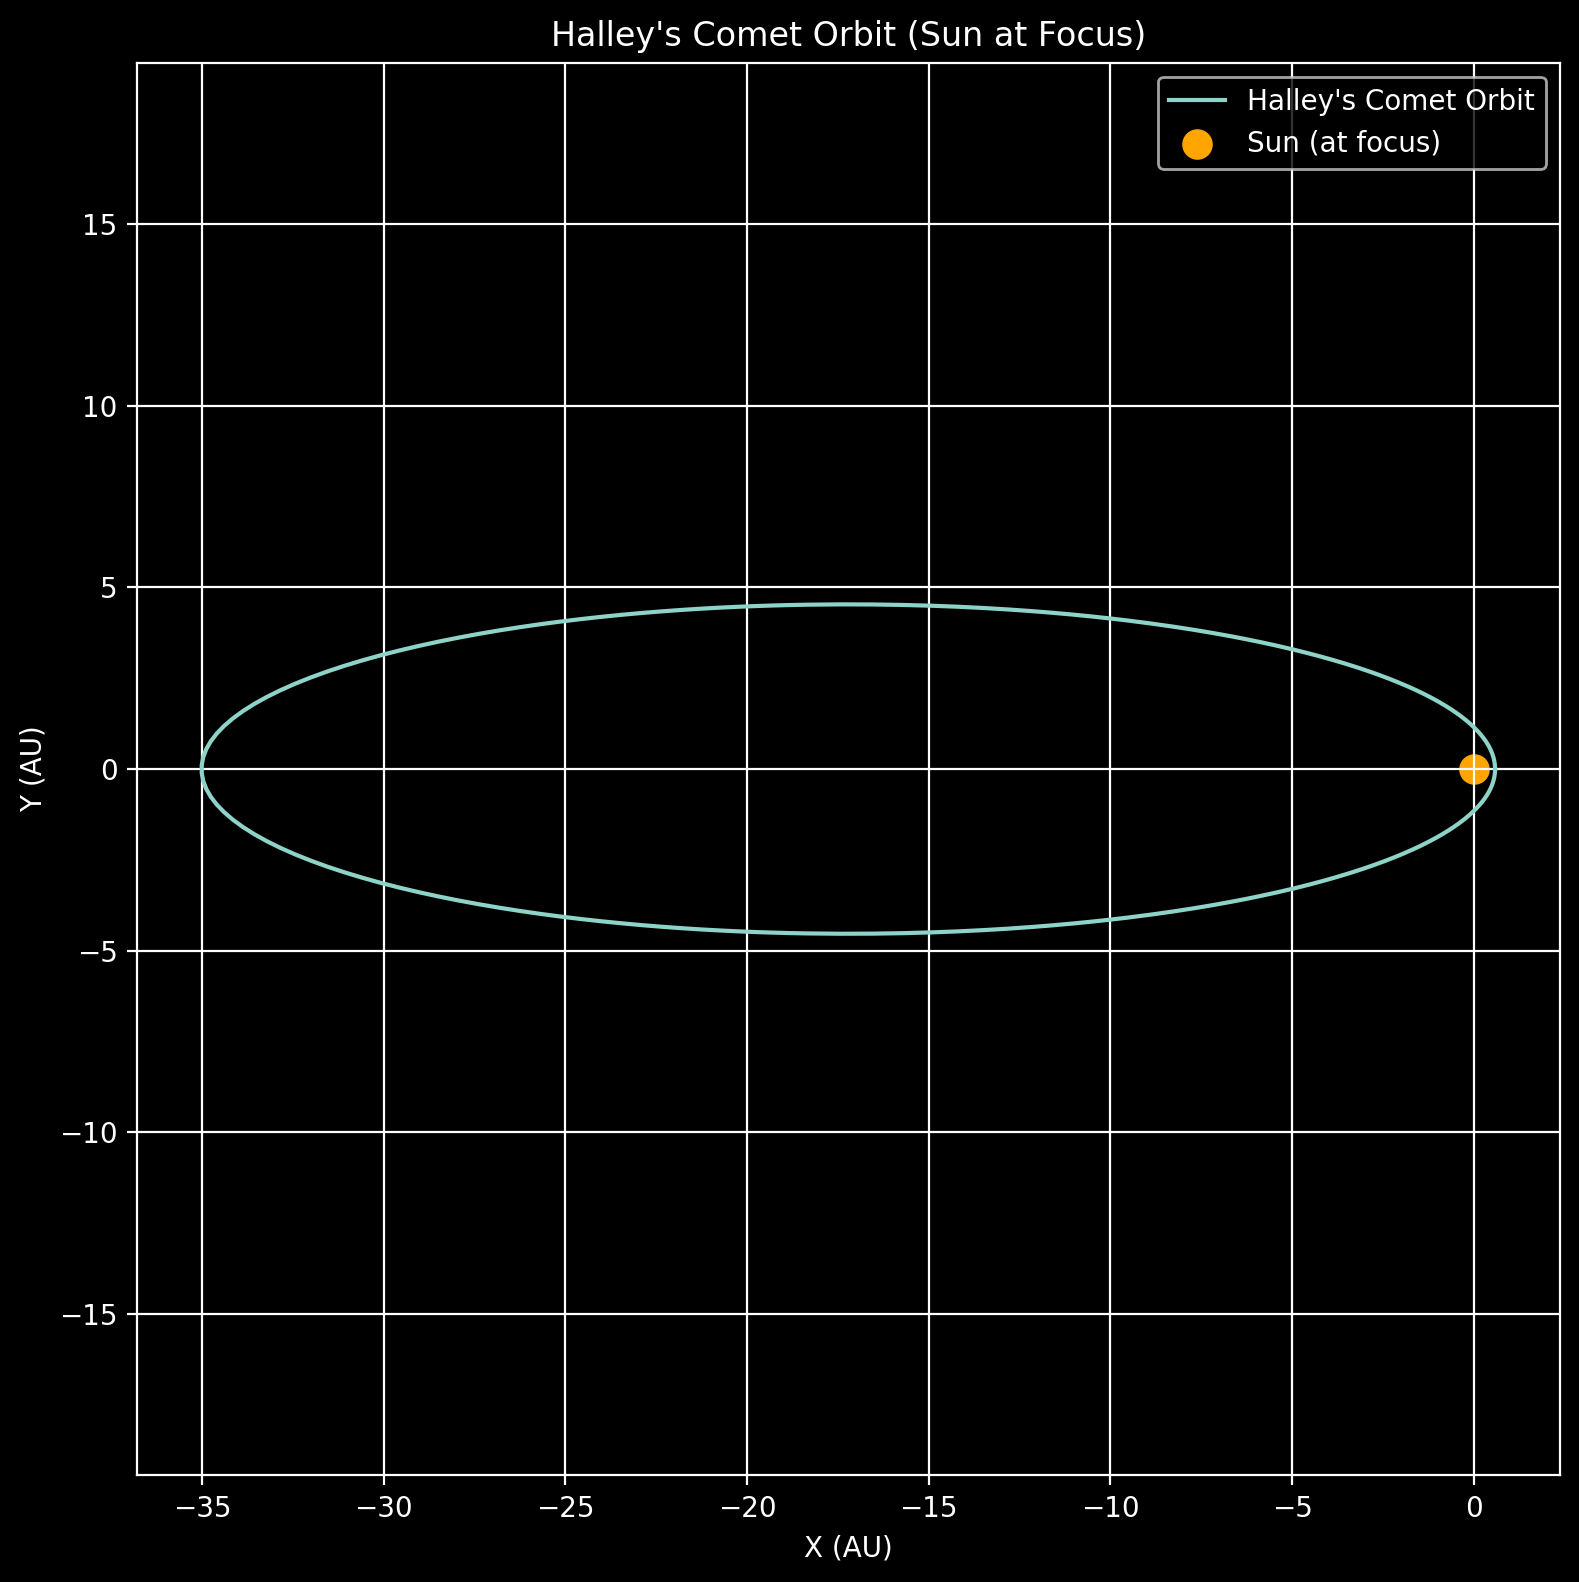

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# === Symbolic setup ===
theta = sp.symbols('theta', real=True)
a, e = sp.symbols('a e', real=True, positive=True)

# Polar equation of an ellipse (r as a function of theta)
r = (a * (1 - e**2)) / (1 + e * sp.cos(theta))

# Convert to Cartesian coordinates
x = r * sp.cos(theta)
y = r * sp.sin(theta)

# === Substitute Halley's Comet parameters ===
a_val = 17.8   # Semi-major axis in AU
e_val = 0.967  # Eccentricity

x_func = x.subs({a: a_val, e: e_val})
y_func = y.subs({a: a_val, e: e_val})

# === Lambdify for plotting ===
x_lamb = sp.lambdify(theta, x_func, modules='numpy')
y_lamb = sp.lambdify(theta, y_func, modules='numpy')

theta_vals = np.linspace(0, 2 * np.pi, 1000)
x_vals = x_lamb(theta_vals)
y_vals = y_lamb(theta_vals)

# === Plotting ===
plt.figure(figsize=(8, 8))
plt.plot(x_vals, y_vals, label="Halley's Comet Orbit")
plt.scatter(0, 0, marker='o', s=100, label='Sun (at focus)', color='orange')
plt.title("Halley's Comet Orbit (Sun at Focus)")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


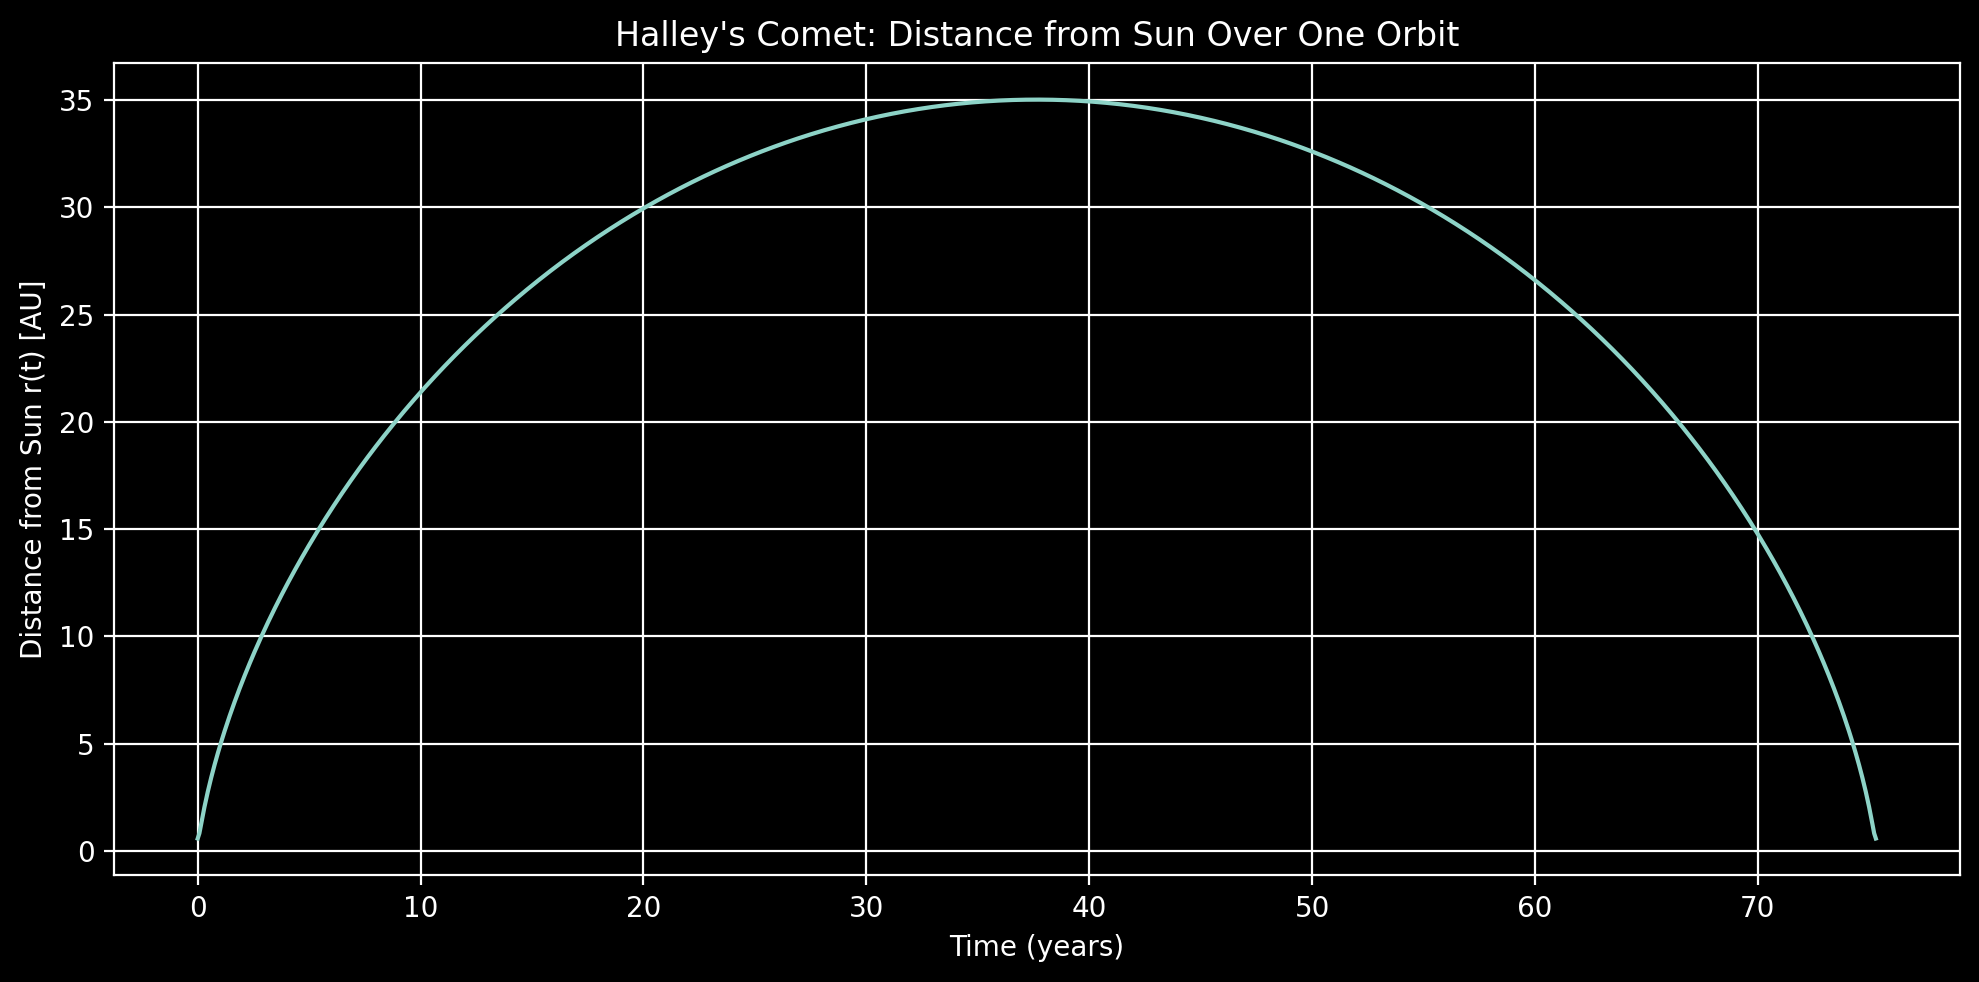

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton

# --- Symbolic setup (from earlier) ---
eccentric_anomaly = sp.Symbol('eccentric_anomaly', real=True)
semi_major_axis = sp.Symbol('semi_major_axis', real=True, positive=True)
eccentricity = sp.Symbol('eccentricity', real=True, positive=True)

# Orbital radius as a function of eccentric anomaly
orbital_radius_expr = semi_major_axis * (1 - eccentricity * sp.cos(eccentric_anomaly))
r_of_E = sp.lambdify((eccentric_anomaly, semi_major_axis, eccentricity), orbital_radius_expr, modules='numpy')

# --- Parameters for Halley's Comet ---
a_val = 17.8             # AU
e_val = 0.967
T_val = 75.3             # years

# Time array over one orbit
t_vals = np.linspace(0, T_val, 1000)
M_vals = 2 * np.pi * t_vals / T_val  # Mean anomaly M(t)

# --- Solve Kepler's Equation for E ---
def solve_kepler(M, e):
    # Solve: M = E - e*sin(E)
    func = lambda E: E - e * np.sin(E) - M
    return newton(func, M)  # Use M as initial guess

E_vals = np.array([solve_kepler(M, e_val) for M in M_vals])

# --- Compute radius r(t) ---
r_vals = r_of_E(E_vals, a_val, e_val)

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(t_vals, r_vals)
plt.xlabel('Time (years)')
plt.ylabel('Distance from Sun r(t) [AU]')
plt.title("Halley's Comet: Distance from Sun Over One Orbit")
plt.grid(True)
plt.tight_layout()
plt.show()

### Constant Acceleration Example

We start with the relationships between **acceleration** $a(t)$, **velocity** $v(t)$, and **position** $x(t)$:

- **Derivative notation:**
    - $a(t) = \frac{dv}{dt}$
    - $v(t) = \frac{dx}{dt}$

- **Function prime notation:**
    - $a(t) = v'(t)$
    - $v(t) = x'(t)$

---

### Step 1: Integrating Acceleration to get Velocity

Given constant acceleration $a(t) = a_0$:

$$
v(t) = \int a_0 \, dt + C_1
$$

If $v(0) = 0$ (starts from rest), then $C_1 = 0$:

$$
v(t) = a_0 t
$$

---

### Step 2: Integrating Velocity to get Position

$$
x(t) = \int v(t) \, dt + C_2
$$

Substitute $v(t) = a_0 t$:

$$
x(t) = \int a_0 t \, dt + C_2
$$

If $x(0) = 0$ (starts at the origin), then $C_2 = 0$:

$$
x(t) = \frac{1}{2} a_0 t^2
$$

---

### Final Result (for $a_0 = 2 \ \mathrm{m/s^2}$):

$$
v(t) = 2t \quad\text{and}\quad x(t) = t^2
$$

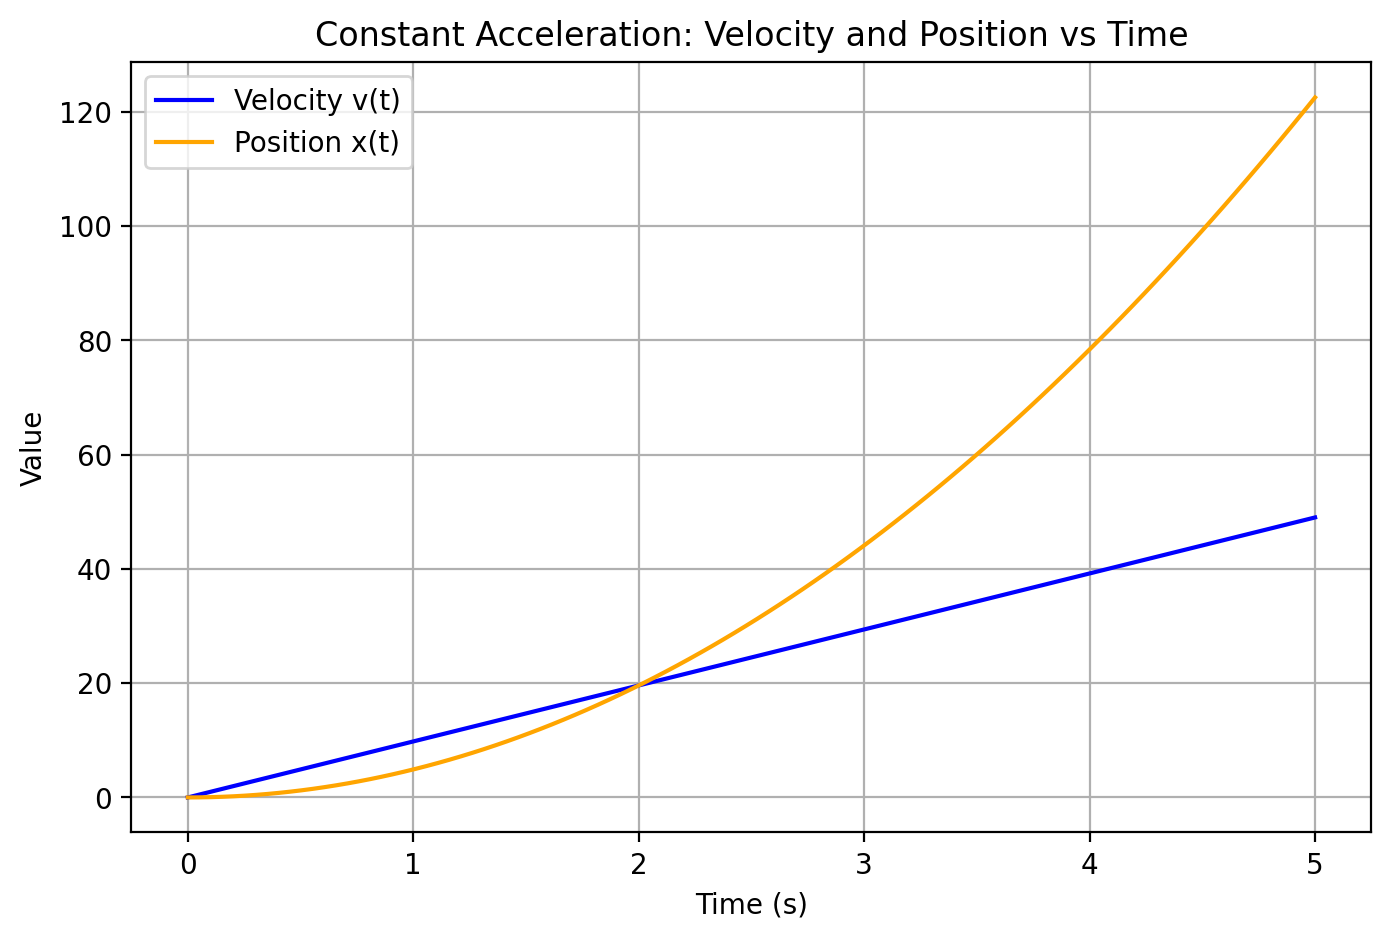

Velocity v(t) = 9.8*t


'Position x(t) ='

4.9*t**2

4.9*t**2

In [4]:
from sympy import symbols, integrate, Eq, solve
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define variables
t = symbols('t', real=True)
a = 9.8  # constant acceleration in m/s^2

# Step 2: Integrate acceleration -> velocity + C1
C1 = symbols('C1')
v = integrate(a, t) + C1

# Step 3: Apply initial velocity v(0) = 0
C1_sol = solve(Eq(v.subs(t, 0), 0), C1)[0]
v = v.subs(C1, C1_sol)  # v = 2*t

# Step 4: Integrate velocity -> position + C2
C2 = symbols('C2')
x = integrate(v, t) + C2

# Step 5: Apply initial position x(0) = 0
C2_sol = solve(Eq(x.subs(t, 0), 0), C2)[0]
x = x.subs(C2, C2_sol)  # x = t**2

# Step 6: Convert to numeric functions for plotting
v_func = lambda t_val: float(v.subs(t, t_val))
x_func = lambda t_val: float(x.subs(t, t_val))

# Step 7: Create time values and compute v(t) and x(t)
t_vals = np.linspace(0, 5, 100)
v_vals = [v_func(tv) for tv in t_vals]
x_vals = [x_func(tv) for tv in t_vals]

# Step 8: Plot results
plt.figure(figsize=(8,5))
plt.plot(t_vals, v_vals, label='Velocity v(t)', color='blue')
plt.plot(t_vals, x_vals, label='Position x(t)', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('Constant Acceleration: Velocity and Position vs Time')
plt.legend()
plt.grid(True)
plt.show()

print("Velocity v(t) =", v)
display("Position x(t) =", x)
display(x)

### Falling Object with Linear Air Drag

The equation of motion is:

$$
m \frac{dv}{dt} = mg - b v
$$

---

#### Definitions:
- **$m$**: mass of the object (kg)  
- **$v(t)$**: velocity at time $t$ (m/s)  
- **$\frac{dv}{dt}$**: acceleration (rate of change of velocity) (m/s²)  
- **$g$**: gravitational acceleration ($\approx 9.81\ \mathrm{m/s^2}$ on Earth)  
- **$b$**: drag coefficient (kg/s), representing strength of air resistance  
- **$mg$**: weight of the object (N), downward force due to gravity  
- **$b v$**: upward drag force proportional to velocity (N)

---

#### Physical meaning:
- **Left side** ($m \frac{dv}{dt}$): mass × acceleration = net force  
- **Right side** ($mg - b v$): gravity pulls down, air drag pushes up  
- As $v$ increases, $b v$ grows until it balances $mg$ → **terminal velocity**  

---

#### Terminal velocity $v_T$:
When $\frac{dv}{dt} = 0$ (no acceleration):

$$
mg - b v_T = 0
$$
$$
v_T = \frac{mg}{b}
$$

Eq(v(t), g*m/b - g*m*exp(-b*t/m)/b)

Symbolic v(t) =


g*m/b - g*m*exp(-b*t/m)/b

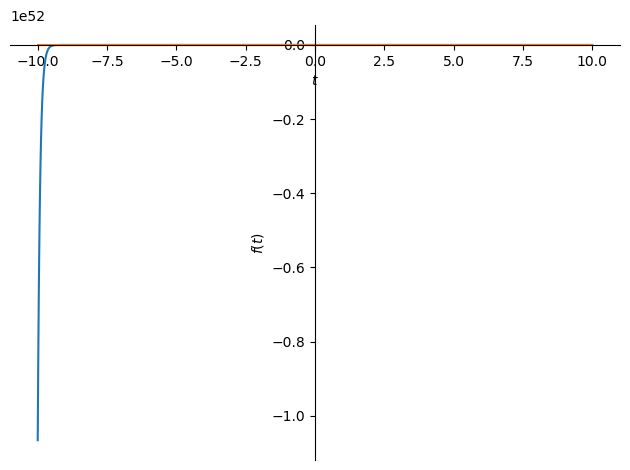


Verification (should match):
LHS = g*m*exp(-b*t/m)
RHS = g*m*exp(-b*t/m)


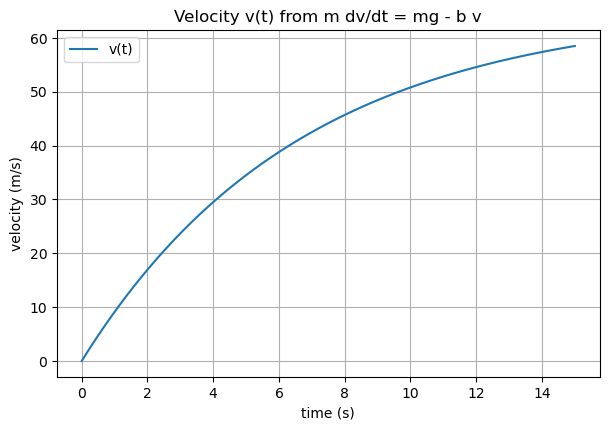


Terminal velocity v_T = mg/b = 65.400 m/s


In [4]:
# Step-by-step: from m dv/dt = mg - b v  to v(t), then plot v(t)
#
# We'll do four steps:
# 1) Define symbols and the differential equation.
# 2) Solve the ODE symbolically with the initial condition v(0)=0.
# 3) (Optional) Verify the solution satisfies the ODE.
# 4) Turn v(t) into a numeric function and plot it.
#
# NOTE: We intentionally keep the plot simple (no custom colors/styles).

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Function, Eq, dsolve, simplify, lambdify,plot

# 1) Symbols and function
t = symbols('t', real=True, nonnegative=True) #time
m = symbols('m', positive=True)  # mass of the object
g = symbols('g', positive=True)  # gravitational acceleration
b = symbols('b', positive=True)  # drag coefficient
v = Function('v') # v(t)

# Differential equation and initial condition v(0)=0
'''ODE stands for Ordinary Differential Equation.
	•	Differential equation: an equation that relates a function (like v(t)) to its derivatives (like \tfrac{dv}{dt}).
	•	Ordinary: means it has derivatives with respect to a single variable (here, time t).
 '''
ode = Eq(m * v(t).diff(t), m*g - b*v(t))
# Initial condition
ics = {v(0): 0}

# 2) Solve symbolically
sol = dsolve(ode, ics=ics)
display(sol)
v_t = simplify(sol.rhs)  # symbolic v(t)
print("Symbolic v(t) =")
display(v_t)
vCurve=v_t.subs({m: 1, g: 9.81, b: 12.0})
plot(vCurve,t)


# 3) Verify (optional): plug back into the ODE's left & right sides
lhs = simplify(m * v_t.diff(t))
rhs = simplify(m*g - b*v_t)
print("\nVerification (should match):")
print("LHS =", lhs)
print("RHS =", rhs)

# 4) Numeric parameters, lambdify, and plot
params = {m: 80.0, g: 9.81, b: 12.0}  # example values
v_num = lambdify(t, v_t.subs(params), 'numpy')

T = 15.0
tt = np.linspace(0, T, 400)
vv = v_num(tt)

plt.figure(figsize=(7,4.5))
plt.plot(tt, vv, label='v(t)')
plt.xlabel('time (s)')
plt.ylabel('velocity (m/s)')
plt.title('Velocity v(t) from m dv/dt = mg - b v')
plt.legend()
plt.grid(True)
plt.show()

# Show terminal velocity computed from the closed form (mg/b) for the chosen params
v_T = float((m*g/b).subs(params))
print(f"\nTerminal velocity v_T = mg/b = {v_T:.3f} m/s")